In [ ]:
!pip install git+https://github.com/MSMRo/signalDraw-isb.git
!pip install neurokit2
!pip install mne neurokit2
import neurokit2 as nk
from signaldraw_isb import SignalDraw
import numpy as np
from scipy.signal import firwin,lfilter,butter,filtfilt,medfilt,iirnotch,resample,correlate
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq



  Cloning https://github.com/MSMRo/signalDraw-isb.git to /tmp/pip-req-build-zica8m3a
  Running command git clone --filter=blob:none --quiet https://github.com/MSMRo/signalDraw-isb.git /tmp/pip-req-build-zica8m3a
  Resolved https://github.com/MSMRo/signalDraw-isb.git to commit ff5c22c821b47b98f0f8c154c163540086ae2b8d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


PREGUNTA 1

In [ ]:
ui = SignalDraw()
ui

Este es el FFT sacado del UI antes de aplicar el filtro

*   Elemento de lista
*   Elemento de lista



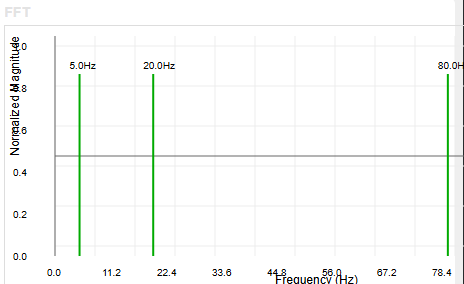

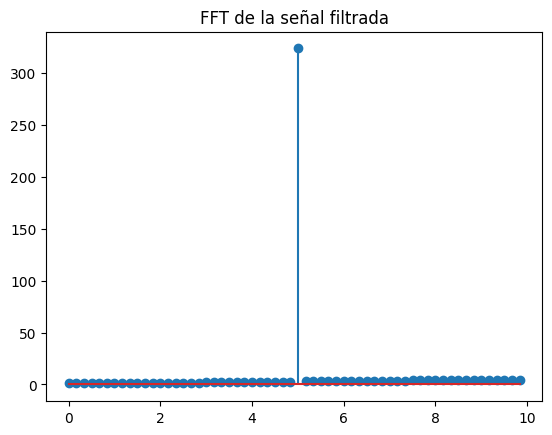

In [ ]:
#Sacó los datos del ui:
fs = 1000
signal_input = ui.signal
#Uso la ayuda para crear el fir:
n_muestras = len(signal_input)
t = np.linspace(0, n_muestras /fs, n_muestras,endpoint=False)
N = 101
f1,f2 = 15,30
fir = firwin(N,[f1, f2],pass_zero=False,fs=fs)
#Aplicamos el filtro
filtered = lfilter(fir, 1.0, signal_input)
#Hallamos la FFT
fft_res = np.abs(np.fft.rfft(filtered))
f_axis = np.fft.rfftfreq(len(filtered),1/fs)
plt.stem(f_axis[:60],fft_res[:60])
plt.title("FFT de la señal filtrada")
plt.show()

PREGUNTA 2

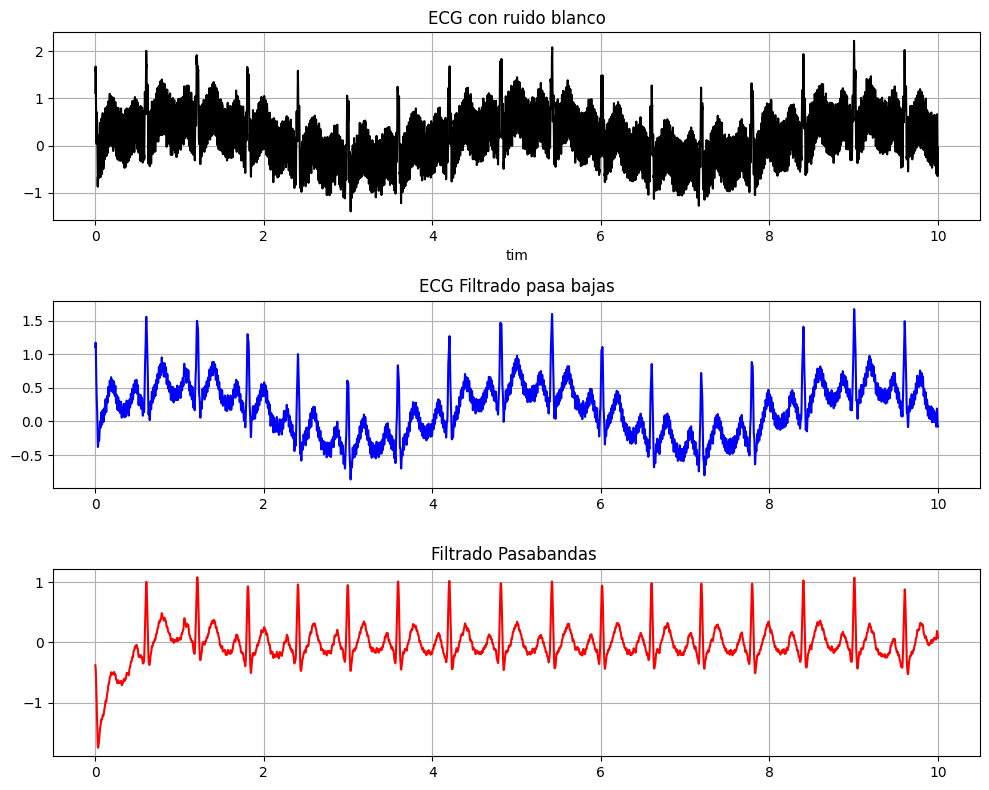

In [ ]:
#Parámetros
fs = 1000
duracion = 10
#ECG
ecg_clean= nk.ecg_simulate(duration=duracion,sampling_rate=fs,heart_rate=100)
t = np.linspace(0,duracion,len(ecg_clean),endpoint=False)
#Ruido
noise = np.random.normal(0,0.08, len(t))
#Interferencia eléctrica f=60 Hz
inter = 0.5*np.sin(2*np.pi*60*t)
#Respiración
respi = 0.4*np.sin(2*np.pi*0.25*t)
#señal total
ECG = ecg_clean+noise+inter+respi
#Butterworth- Pasabajas
N = 4
fc_low = 50.0
b,a = butter(N, fc_low, btype='low', fs=fs)
ecg_lowpass = filtfilt(b, a, ECG)
#Pasabandas
fc_low_band = 0.5
fc_high_band = 40.0
b, a = butter(N,[fc_low_band, fc_high_band], btype='band', fs=fs)
ecg_bandpass = filtfilt(b, a, ECG)
plt.figure(figsize=(10, 8))
plt.subplot(3,1,1)
plt.title("ECG con ruido blanco")
plt.plot(t,ECG,color='black')
plt.xlabel("tim")
plt.grid(True)
plt.subplot(3, 1, 2)
plt.title("ECG Filtrado pasa bajas")
plt.plot(t, ecg_lowpass, color='blue')
plt.grid(True)
plt.subplot(3, 1, 3)
plt.title(f"Filtrado Pasabandas ")
plt.plot(t, ecg_bandpass, color='red')
plt.grid(True)
plt.tight_layout()
plt.show()

PREGUNTA 3

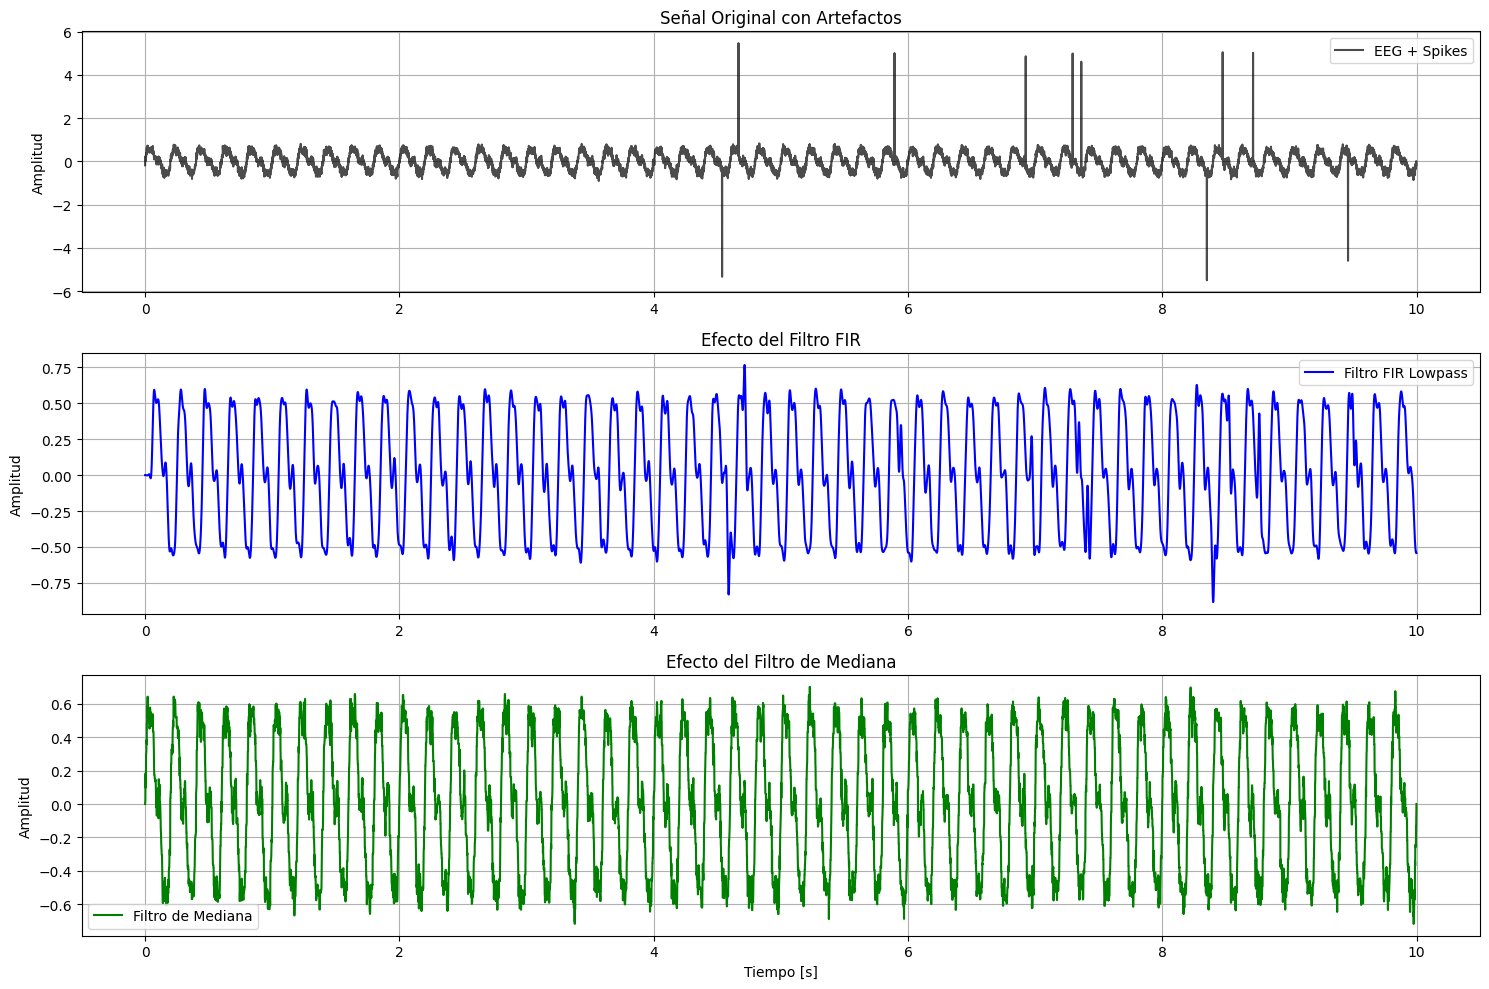

In [ ]:
fs = 1000
t = np.linspace(0, 10, 10 * fs, endpoint=False)
eeg = 0.5 * np.sin(2 * np.pi * 5 * t) + 0.2 * np.sin(2 * np.pi * 10 * t) + 0.1 * np.sin(2 * np.pi * 20 * t) + np.random.normal(0, 0.1, len(t))

eeg_con_ruido = eeg.copy()
# Generamos 10 posiciones aleatorias para los picos
indices_spikes = np.random.randint(0, len(eeg), 10)

for idx in indices_spikes:
    eeg_con_ruido[idx] += np.random.choice([-5, 5])

numtaps = 101
fir_coeff = firwin(numtaps, 40, fs=fs)
eeg_fir = lfilter(fir_coeff, 1.0, eeg_con_ruido)

eeg_mediana = medfilt(eeg_con_ruido, kernel_size=5)

plt.figure(figsize=(15, 10))

# Gráfica 1
plt.subplot(3, 1, 1)
plt.plot(t, eeg_con_ruido, color='black', alpha=0.7, label='EEG + Spikes')
plt.title("Señal Original con Artefactos")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)

# Gráfica 2
plt.subplot(3, 1, 2)
plt.plot(t, eeg_fir, color='blue', label='Filtro FIR Lowpass')
plt.title("Efecto del Filtro FIR")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)

# Gráfica 3 Mediana
plt.subplot(3, 1, 3)
plt.plot(t, eeg_mediana, color='green', label='Filtro de Mediana')
plt.title("Efecto del Filtro de Mediana")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

PREGUNTA 4

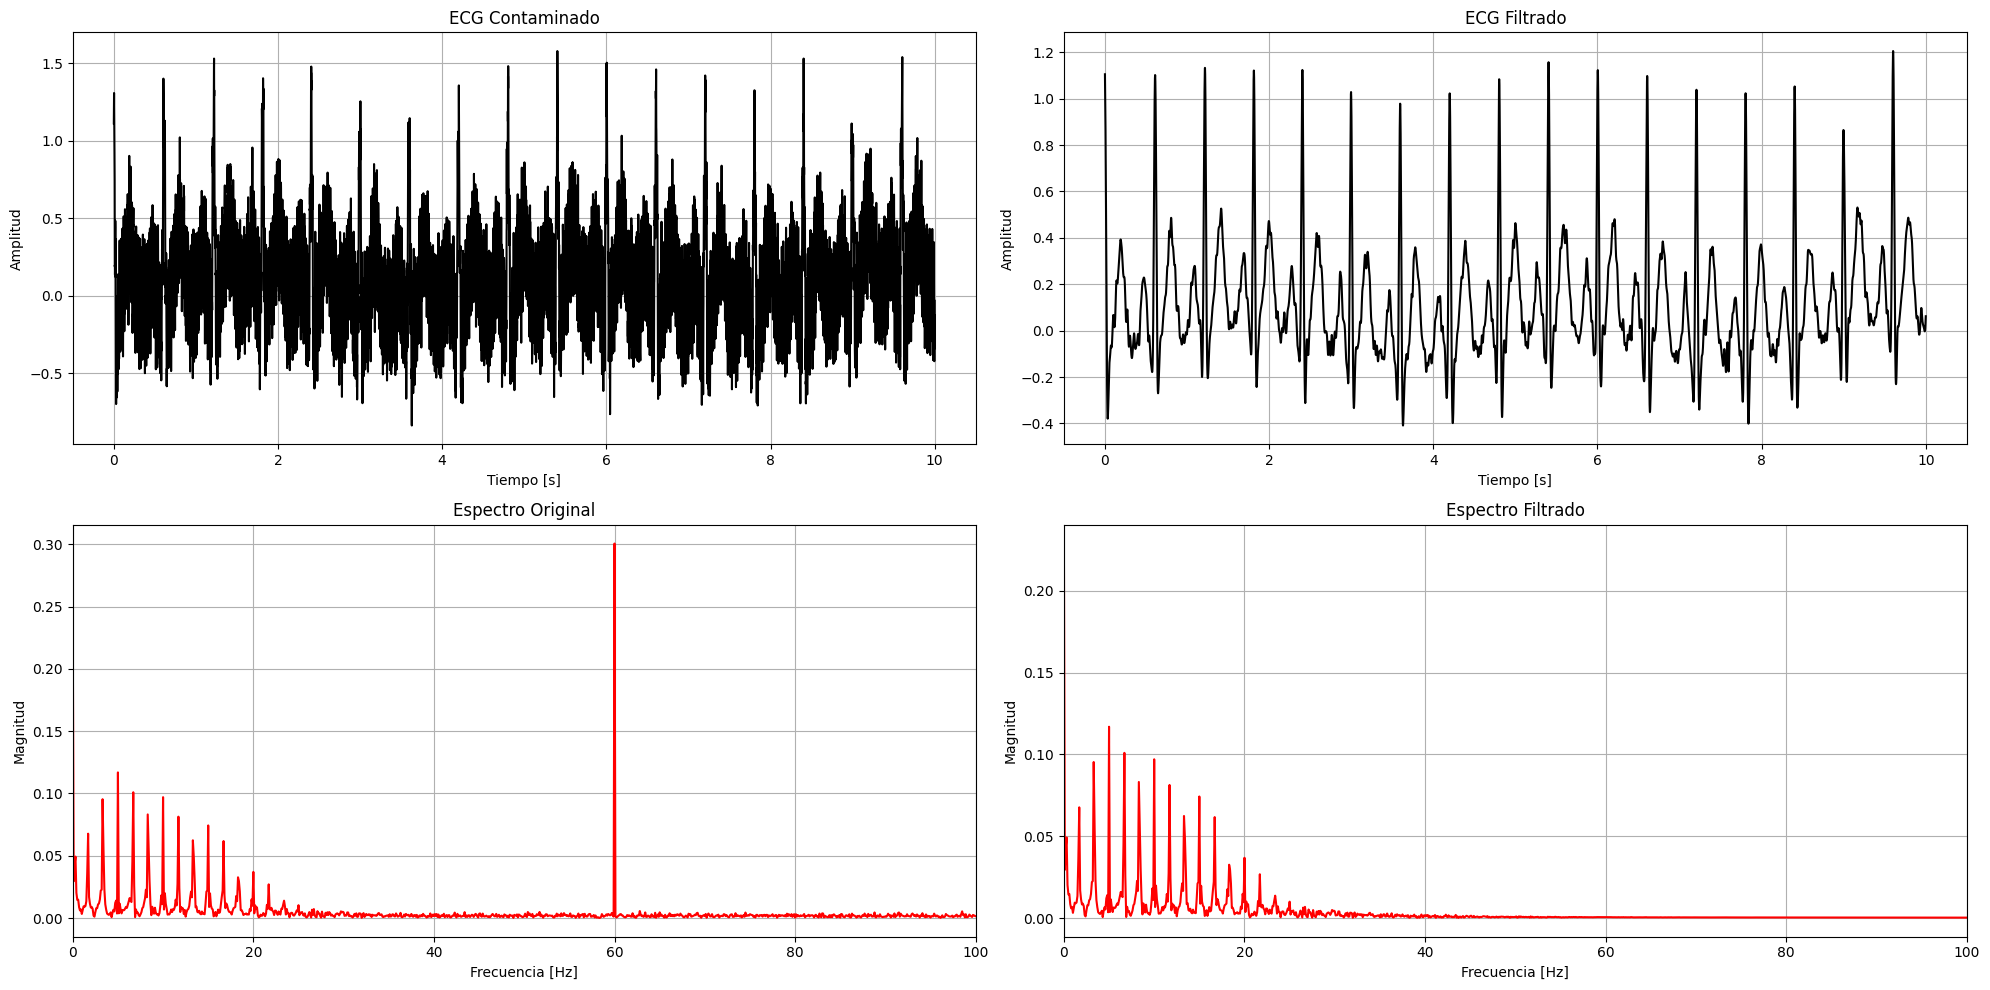

In [ ]:
#Parámetros iniciales:
fs = 1000
duracion = 10
#Creación de señales
ecg_limpio = nk.ecg_simulate(duration=duracion,sampling_rate=fs,heart_rate=100)
#Vector tiempo
t = np.arange(len(ecg_limpio)) / fs
#Ruido eléctrico
ruido_60hz = 0.3 * np.sin(2 * np.pi * 60 * t)
#Ruido blanco
ruido_blanco = np.random.normal(0, 0.1, len(t))
#Sumamos los ruidos
noisy_ecg = ecg_limpio + ruido_60hz + ruido_blanco
#Aplicamos fultro notch
b_notch, a_notch = iirnotch(60.0, 30.0, fs)
ecg_sin_60hz = filtfilt(b_notch, a_notch, noisy_ecg)
#Aplicamos butter
b_low, a_low = butter(4, 40.0, btype='low', fs=fs)
ecg_filtrado_final = filtfilt(b_low, a_low, ecg_sin_60hz)
N = len(t)
#FFT
frecuencias = fftfreq(N, 1/fs)[:N//2]
fft_noisy = 2.0/N * np.abs(fft(noisy_ecg)[:N//2])
fft_filtered = 2.0/N * np.abs(fft(ecg_filtrado_final)[:N//2])
#Ploteo
plt.figure(figsize=(20, 10))
plt.subplot(2, 2, 1)
plt.plot(t, noisy_ecg, color='black')
plt.title('ECG Contaminado')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)
plt.subplot(2, 2, 2)
plt.plot(t, ecg_filtrado_final, color='black')
plt.title('ECG Filtrado')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)
plt.subplot(2, 2, 3)
plt.plot(frecuencias, fft_noisy, color='red')
plt.title('Espectro Original')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud')
plt.xlim(0, 100)
plt.grid(True)
plt.subplot(2, 2, 4)
plt.plot(frecuencias, fft_filtered, color='red')
plt.title('Espectro Filtrado')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud')
plt.xlim(0, 100)
plt.grid(True)
plt.tight_layout()
plt.show()


PREGUNTA 5

Delay estimado para ECG: 0 muestras (0.0 segundos)
Delay estimado para Respiración: -1000 muestras (1.0 segundos)
Delay estimado para Acelerómetro: 0 muestras (0.0 segundos)


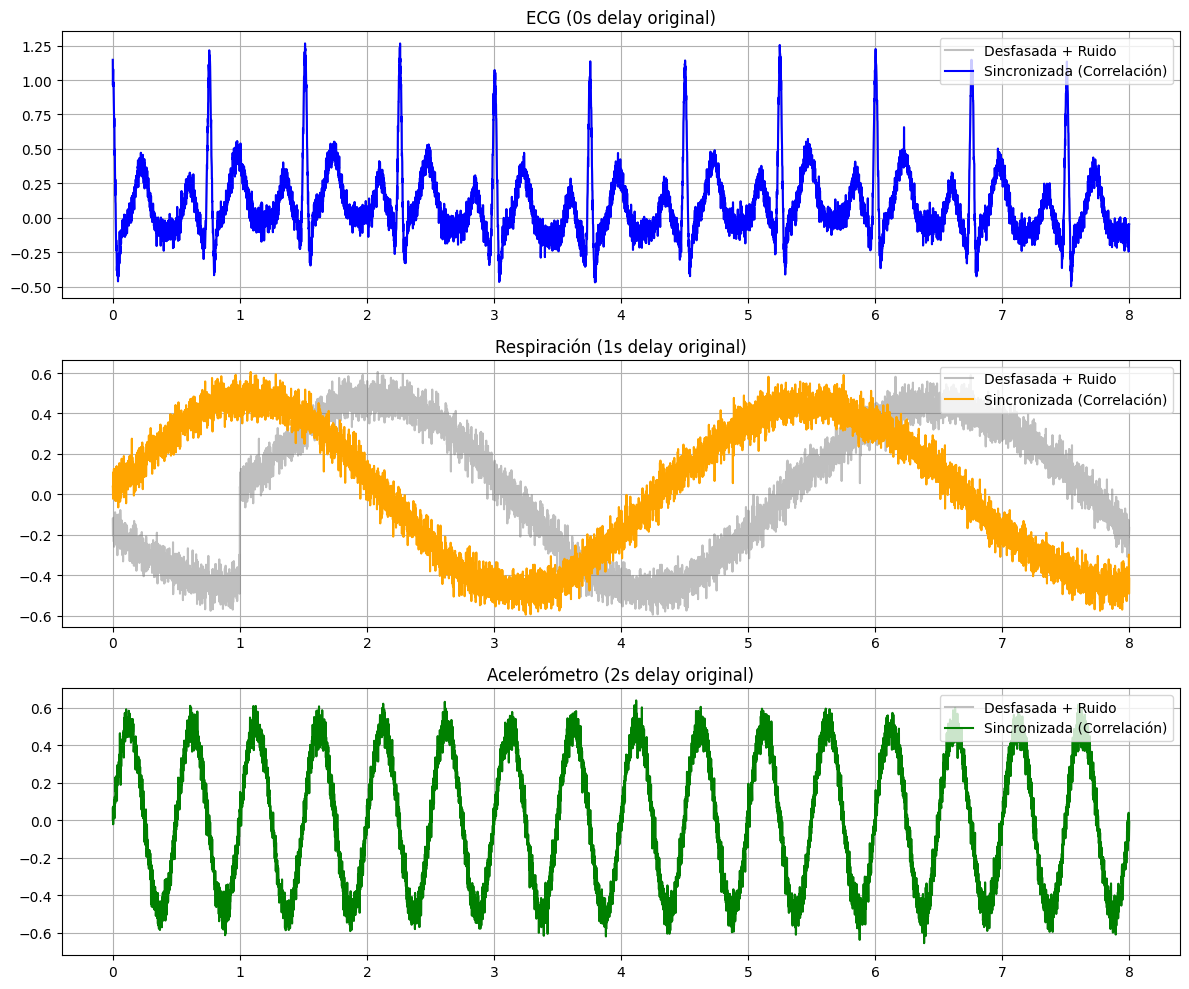

In [ ]:
#parametros
fs = 1000
duracion = 8
t = t = np.linspace(0, duracion, duracion * fs, endpoint=False)

#Señales }
ecg = nk.ecg_simulate(duration=duracion, sampling_rate=fs, heart_rate=80)
resp = nk.rsp_simulate(duration=duracion, sampling_rate=fs, respiratory_rate=15)
acc = nk.signal_simulate(duration=duracion, sampling_rate=fs, frequency=2.0) #aceleromeetro

#delays para cada unio
delay_ecg_muestras = int(0 * fs) # 0 seg
delay_resp_muestras = int(1.0 * fs) # 1seg
delay_acc_muestras = int(2.0 * fs) # 2 seg

#aplicamos el ruido + delay
ecg_ruidoso_delay = np.roll(ecg, delay_ecg_muestras) + np.random.normal(0, 0.05, len(t))
resp_ruidoso_delay = np.roll(resp, delay_resp_muestras) + np.random.normal(0, 0.05, len(t))
acc_ruidoso_delay = np.roll(acc, delay_acc_muestras) + np.random.normal(0, 0.05, len(t))
#sincronizamos
def sincronizar_señal(s1, s2, nombre):
    corr = correlate(s1, s2, mode='full')
    estimated_delay = np.argmax(corr) - (len(s1) - 1)

    print(f"Delay estimado para {nombre}: {estimated_delay} muestras ({abs(estimated_delay)/fs} segundos)")

    s2_sincronizada = np.roll(s2, estimated_delay)
    return s2_sincronizada


ecg_sync = sincronizar_señal(ecg, ecg_ruidoso_delay, "ECG")
resp_sync = sincronizar_señal(resp, resp_ruidoso_delay, "Respiración")
acc_sync = sincronizar_señal(acc, acc_ruidoso_delay, "Acelerómetro")

plt.figure(figsize=(12, 10))

def plot_comparativa(pos, señal_desfasada, señal_sync, titulo, color):
    plt.subplot(3, 1, pos)
    plt.title(titulo)
    plt.plot(t, señal_desfasada, color='gray', alpha=0.5, label='Desfasada + Ruido')
    plt.plot(t, señal_sync, color=color, linewidth=1.5, label='Sincronizada (Correlación)')
    plt.legend(loc='upper right')
    plt.grid(True)

plot_comparativa(1, ecg_ruidoso_delay, ecg_sync, "ECG (0s delay original)", 'blue')
plot_comparativa(2, resp_ruidoso_delay, resp_sync, "Respiración (1s delay original)", 'orange')
plot_comparativa(3, acc_ruidoso_delay, acc_sync, "Acelerómetro (2s delay original)", 'green')

plt.tight_layout()
plt.show()

PREGUNTA 6

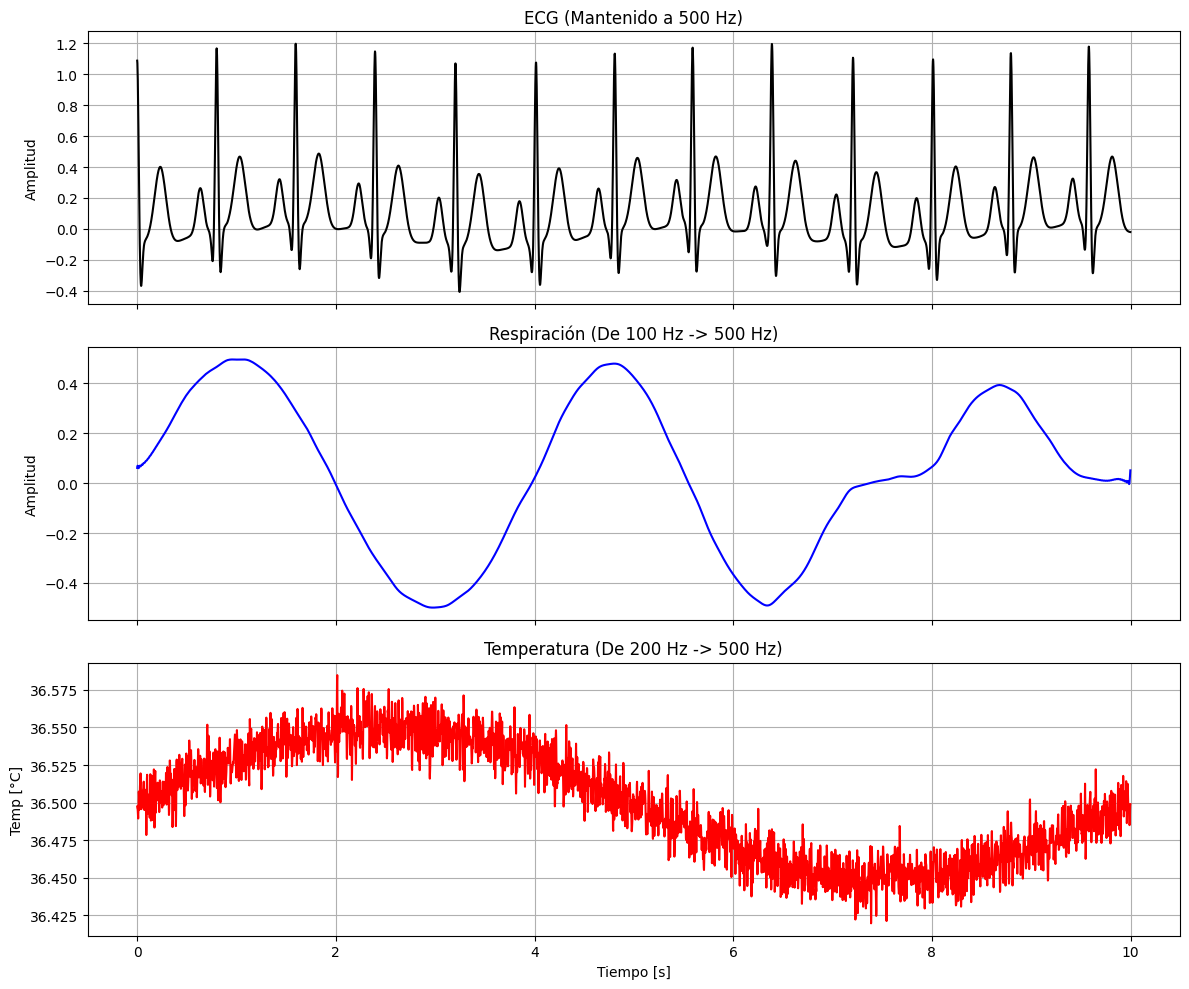

In [ ]:
#Duración de todo
duracion = 10
# ECG a 500 Hz
fs_ecg = 500
ecg_original = nk.ecg_simulate(duration=duracion, sampling_rate=fs_ecg, heart_rate=75)
t_ecg = np.linspace(0, duracion, len(ecg_original), endpoint=False)
#Respiración a 100 Hz
fs_resp = 100
resp_original = nk.rsp_simulate(duration=duracion, sampling_rate=fs_resp, respiratory_rate=15)
t_resp = np.linspace(0, duracion, len(resp_original), endpoint=False)
#Temperatura a 200 Hz
fs_temp = 200
t_temp = np.linspace(0, duracion, duracion * fs_temp, endpoint=False)
temp_original = 36.5 + 0.05 * np.sin(2 * np.pi * 0.1 * t_temp) + np.random.normal(0, 0.01, len(t_temp))
# Resampling
fs_comun = 500
muestras_comunes = duracion * fs_comun
resp_resampled = resample(resp_original, muestras_comunes)
temp_resampled = resample(temp_original, muestras_comunes)
t_comun = np.linspace(0, duracion, muestras_comunes, endpoint=False)
#Graficas;
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
# ECG
ax1.plot(t_comun, ecg_original, color='black')
ax1.set_title('ECG (Mantenido a 500 Hz)')
ax1.set_ylabel('Amplitud')
ax1.grid(True)
# Respiración
ax2.plot(t_comun, resp_resampled, color='blue')
ax2.set_title('Respiración (De 100 Hz -> 500 Hz)')
ax2.set_ylabel('Amplitud')
ax2.grid(True)
# Temperatura
ax3.plot(t_comun, temp_resampled, color="red")
ax3.set_title("Temperatura (De 200 Hz -> 500 Hz)")
ax3.set_xlabel("Tiempo [s]")
ax3.set_ylabel("Temp [°C]")
ax3.grid(True)
plt.tight_layout()
plt.show()